In [2]:
# importing required modules
import matplotlib.pyplot as plt
from vasttools.query import Query
import pandas as pd

from vasttools.moc import VASTMOCS
from astropy import units as u

import numpy as np

from astropy.coordinates import SkyCoord

import scipy.stats as stats

In [3]:
# setting plot preferences
%matplotlib inline

In [4]:
psr_df = pd.read_csv('final_products/paper_df_postprocessed.csv')

In [5]:
raw_psr_meas = {}
dates = {}

In [6]:
for name in psr_df['JNAME'].values:
    psr_name = name
    
    if (np.isnan(psr_df[psr_df['JNAME']==name]['control_chi2'].iloc[0])):
        continue

    #query_coord = controls_df.sort_values('chi_squared', ascending=False).iloc[0]['skycoord']
    query_coord = SkyCoord(str(psr_df[psr_df['JNAME']==psr_name].iloc[0]['RAJD']) + " " + str(psr_df[psr_df['JNAME']==psr_name].iloc[0]['DECJD']), unit='deg')
    query = Query(coords=query_coord, epochs='all-vast', use_tiles=True, corrected_data=False)
    query.find_sources()

    psr_meas = query.results[0].measurements[query.results[0].measurements['freq']!=1367.5]
    
    raw_psr_meas[psr_name] = psr_meas
            
    dates[psr_name] = psr_meas['dateobs']
    

Stokes I images unavailable for epoch 1
Stokes I catalogues unavailable for epoch 1
Stokes I RMS maps unavailable for epoch 1
Stokes I images unavailable for epoch 2
Stokes I catalogues unavailable for epoch 2
Stokes I RMS maps unavailable for epoch 2
Stokes I images unavailable for epoch 3x
Stokes I catalogues unavailable for epoch 3x
Stokes I RMS maps unavailable for epoch 3x
Stokes I images unavailable for epoch 4x
Stokes I catalogues unavailable for epoch 4x
Stokes I RMS maps unavailable for epoch 4x
Stokes I images unavailable for epoch 5x
Stokes I catalogues unavailable for epoch 5x
Stokes I RMS maps unavailable for epoch 5x
Stokes I images unavailable for epoch 6x
Stokes I catalogues unavailable for epoch 6x
Stokes I RMS maps unavailable for epoch 6x
Stokes I images unavailable for epoch 7x
Stokes I catalogues unavailable for epoch 7x
Stokes I RMS maps unavailable for epoch 7x
Stokes I images unavailable for epoch 8
Stokes I catalogues unavailable for epoch 8
Stokes I RMS maps u

In [13]:
dates['J1745-3040'][0].to_julian_date() - 2400000.5

59897.32044459507

In [40]:
dates_mjd = {name: (dates_.apply(pd.Timestamp.to_julian_date) - 2400000.5) for name, dates_ in dates.items()}

In [41]:
dates_mjd

{'J1745-3040': 0     59897.320445
 1     59902.279148
 2     59921.150545
 3     59950.151312
 4     59965.073498
 5     59979.091343
 6     59980.091657
 7     59994.942869
 8     59998.056776
 9     60009.915047
 10    60025.874033
 11    60040.841156
 12    60055.787769
 13    60070.751920
 14    60085.713506
 15    60097.672626
 16    60107.674210
 17    60116.626814
 18    60117.680318
 19    60129.601737
 20    60146.558637
 21    60167.583863
 22    60184.521100
 23    60199.380241
 24    60219.433562
 25    60235.295812
 26    60249.331460
 27    60266.284132
 28    60289.214554
 29    60305.087266
 30    60321.277563
 31    60342.007789
 32    60362.011117
 33    60383.892117
 34    60404.899856
 35    60419.875642
 36    60435.827403
 Name: dateobs, dtype: float64,
 'J1804-2717': 0     59897.260656
 1     59902.230188
 2     59921.159646
 3     59950.101526
 4     59965.035943
 5     59979.101480
 6     59980.101795
 7     59994.990562
 8     59998.942673
 9     60009.942695


In [43]:
from astroML.time_series import lomb_scargle, generate_damped_RW
from astroML.time_series import ACF_scargle, ACF_EK

In [58]:
name = 'J1722-3207'

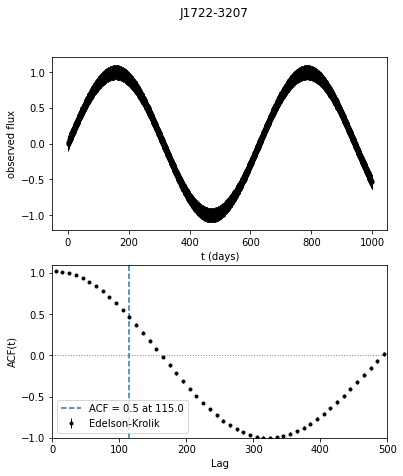

In [94]:
#t = dates_mjd[name] - dates_mjd[name][0]
#dy = raw_psr_meas[name]['rms_image']
#y_obs = raw_psr_meas[name]['flux_peak']

t = np.arange(1000)
dy = 0.1
y_obs = np.sin(0.01 * t)

#------------------------------------------------------------
# compute ACF via E-K method
C_EK, C_EK_err, bins = ACF_EK(t, y_obs, dy, bins=np.linspace(0, 500, 51))
t_EK = 0.5 * (bins[1:] + bins[:-1])

#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(6, 7))

# plot the input data
ax = fig.add_subplot(211)
ax.errorbar(t, y_obs, dy, fmt='.k', lw=1)
ax.set_xlabel('t (days)')
ax.set_ylabel('observed flux')

# plot the ACF
ax = fig.add_subplot(212)

ax.errorbar(t_EK, C_EK, C_EK_err, fmt='.k', lw=1,
            label='Edelson-Krolik')

ax.plot(t_S, 0 * t_S, ':', lw=1, c='gray')

t_point5 = t_EK[np.abs(C_EK - 0.5).argmin()]

ax.axvline(t_point5, linestyle='dashed', label=("ACF = 0.5 at " + str(t_point5)))

ax.legend(loc=3)

ax.set_xlim(0, 500)
ax.set_ylim(-1.0, 1.1)

ax.set_xlabel('Lag')
ax.set_ylabel('ACF(t)')

fig.suptitle(name)
plt.show()

In [86]:
np.abs(C_EK - 0.5).argmin()

11

In [57]:
for name in psr_df['JNAME'].values:
    if not raw_psr_meas[name]['flux_peak'].isnull().values.any():
        print(name)

J1745-3040
J1722-3207
J1720-2933
J1801-2920
J1811-2405
J1801-2304
J1759-3107
J1750-3157
J1816-2650
J1749-3002
J1738-3211
J1721-3532


In [69]:
stuff = ['J1745-3040', 'J1722-3207', 'J1720-2933']

In [81]:
df0 = raw_psr_meas[stuff[0]][['dateobs', 'flux_peak', 'rms_image']]
df1 = raw_psr_meas[stuff[1]][['dateobs', 'flux_peak', 'rms_image']]
df2 = raw_psr_meas[stuff[2]][['dateobs', 'flux_peak', 'rms_image']]

In [82]:
pd.concat([df0, df1, df2], keys=stuff).to_csv('test_lightcurves.csv')